In [1]:
from DayNightAnalysisFunctions import compararElementos, ind2group, writeClusterResults, radar_simple, radar_multiple, getMatrix, getStateMatrix, translateStates, getTransitionMatrix, getIndicesTotal, getIndices, getPatterns, createEmbedding, distCat, distZona, getDistanceMatrix, graficar_agebs_por_cluster 

In [2]:
from CrimeTransmissionFunctions import cargar_agebs

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from sklearn.metrics import jaccard_score
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [4]:
def main( i_crime, crime, n_clusters, gdf_agebs, results_path):

    print("\n" + "-" * 60)
    print("STARTING DAYTIME-NIGHTTIME ANALYSIS")
    print("-" * 60)

    labels, groups, sil = None, None, None
    
    # --- 1. TransitionMatrix ---
    print("\n[1] Transition matrix")
    
    try:

        M_day = getStateMatrix('d', i_crime)
        M_night = getStateMatrix('n', i_crime)

        s_day = translateStates(M_day)
        s_night = translateStates(M_night)

        print("Day state distribution:", dict(zip(*np.unique(s_day, return_counts=True))))
        print("Night state distribution:", dict(zip(*np.unique(s_night, return_counts=True))))

        T = getTransitionMatrix(s_day, s_night)
        print("Transition matrix:\n", T)

        I = getIndices(T)
        print(f"Indices (A, D, P): {I}")


        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(
            T,
            annot=True,
            fmt='.0f',
            cmap='viridis',
            cbar=False,
            square=True,
            linewidths=0.5,
            linecolor='white',
            vmin=0,
            vmax=np.max(T),
            ax=ax
        )
        titulo = f"Transition Matrix Heatmap of {crime}"
        ax.set_title(titulo)
        ax.set_xlabel('Night State', fontsize=12)
        ax.set_ylabel('Day State', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{results_path}/transition_matrix_{crime.lower()}.png', dpi=1200, bbox_inches='tight')
        plt.show() 
        plt.close()
        
        
    except Exception as e:
        print(f"Error creating transition matrix: {e}")


    # --- 2. CLustering ---
    print("\n[2] Hierarchical Agglomerative Clustering with Complete Linkage")
    
    try: 

        A_day = getMatrix('base', 'd', i_crime)
        A_night = getMatrix('base', 'n', i_crime)

        M_day = getStateMatrix('d', i_crime)
        M_night = getStateMatrix('n', i_crime)
        s_day = translateStates(M_day)
        s_night = translateStates(M_night)

        Emb = createEmbedding(s_day, s_night, A_day, A_night)
        Dist = getDistanceMatrix(Emb)
        condensedDist = squareform(Dist)

        Z = linkage(condensedDist, 'complete')


        plt.figure(figsize=(8, 4))
        dendrogram(Z, truncate_mode='lastp', p=20, show_contracted=True)
        plt.title(f"Dendrogram for {crime}")
        plt.savefig(f"{results_path}/dendrogram_{crime.lower()}.png", dpi=1200, bbox_inches='tight')
        plt.close()

        
        labels = fcluster(Z, n_clusters, criterion='maxclust')
        groups = ind2group(labels)
        writeClusterResults(Emb, groups, results_path)

        sil = silhouette_score(Dist, labels, metric='precomputed')
        print(f"Silhouette (Scipy): {sil:.3f}")
        

       # Clustering con sklearn para comparar
        Csk = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete', metric='precomputed').fit(Dist)
        silh = silhouette_score(Dist, Csk.labels_, metric='precomputed')
        print(f"Silhouette (Sklearn): {silh:.3f}")


        clusters = list(labels)
        graficar_agebs_por_cluster(gdf_agebs, clusters, crimen = crime)
    
    except Exception as e:
        print(f"Error creating Hierarchical Clustering: {e}")
    
    
    print("\n" + "-" * 60)
    print("ANALYSIS SUCCESSFULLY COMPLETED")
    print("-" * 60 + "\n")
    
    return labels, groups, sil, T, I

In [5]:
gdf_agebs = cargar_agebs('conjunto de datos/16a.shp')

# Residential burglary


------------------------------------------------------------
STARTING DAYTIME-NIGHTTIME ANALYSIS
------------------------------------------------------------

[1] Transition matrix
Day state distribution: {0.0: 338, 1.0: 19, 2.0: 15, 3.0: 1, 4.0: 13, 5.0: 3, 7.0: 1}
Night state distribution: {0.0: 353, 1.0: 16, 2.0: 8, 3.0: 1, 4.0: 9, 5.0: 2, 7.0: 1}
Transition matrix:
 [[317.   9.   6.   0.   6.   0.   0.   0.]
 [ 12.   0.   1.   0.   3.   2.   0.   1.]
 [ 12.   3.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   0.   0.   0.   0.   0.   0.]
 [ 10.   3.   0.   0.   0.   0.   0.   0.]
 [  2.   0.   1.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   1.   0.   0.   0.   0.]]
Indices (A, D, P): (0.2876712328767123, 0.4931506849315068, 0.2191780821917808, 0.010696190654907112)


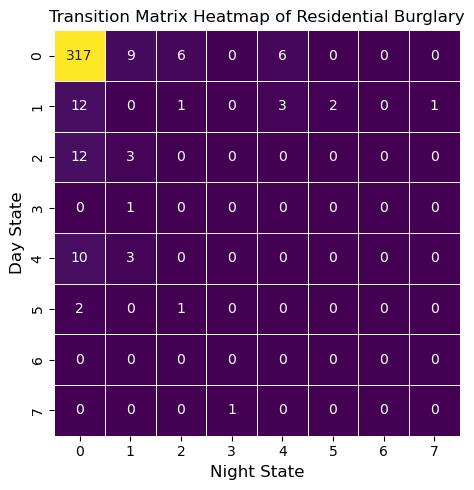


[2] Hierarchical Agglomerative Clustering with Complete Linkage
Silhouette (Scipy): 0.906
Silhouette (Sklearn): 0.906


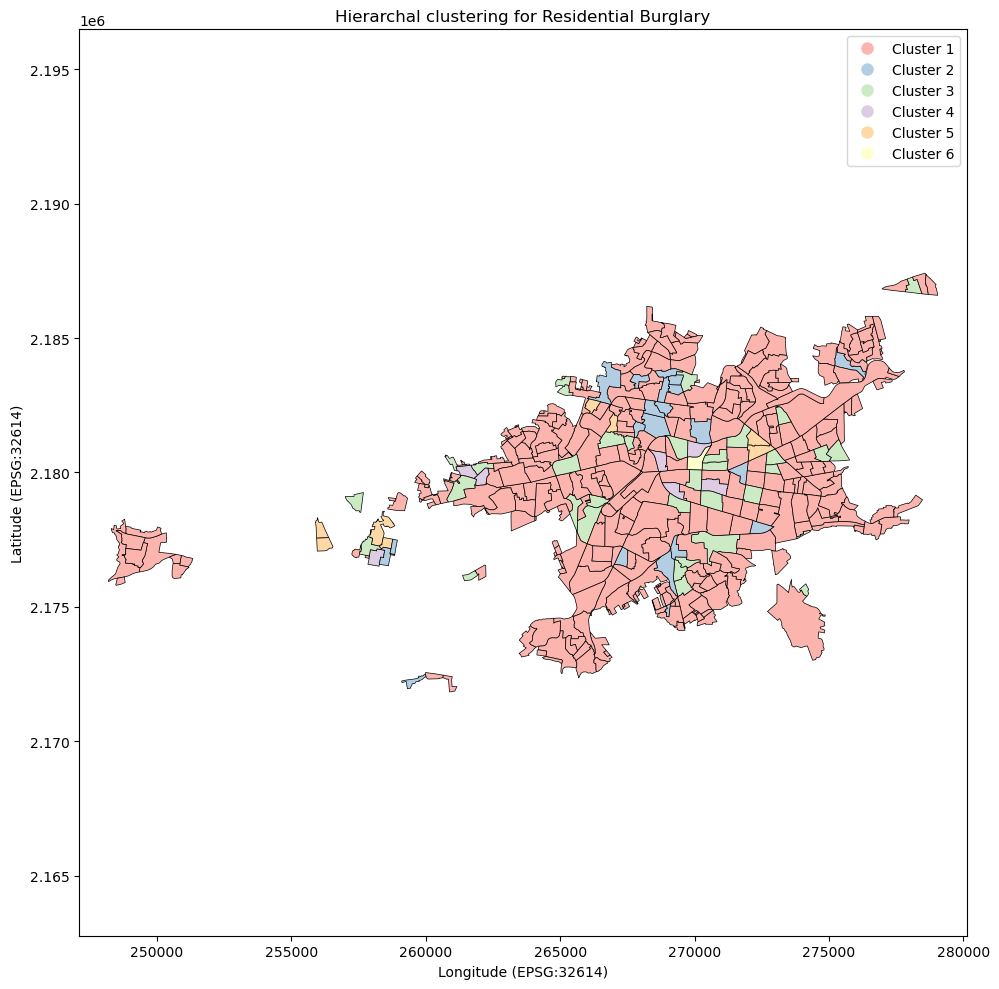


------------------------------------------------------------
ANALYSIS SUCCESSFULLY COMPLETED
------------------------------------------------------------



In [6]:
labels0, groups0, sil0, T0, I0 = main( i_crime = 0, crime = "Residential Burglary", n_clusters = 6, gdf_agebs = gdf_agebs, results_path='./Resultados_RoboCasa/')

# Commercial Robbery


------------------------------------------------------------
STARTING DAYTIME-NIGHTTIME ANALYSIS
------------------------------------------------------------

[1] Transition matrix
Day state distribution: {0.0: 346, 1.0: 9, 2.0: 11, 3.0: 1, 4.0: 9, 5.0: 2, 6.0: 5, 7.0: 7}
Night state distribution: {0.0: 351, 1.0: 11, 2.0: 9, 3.0: 2, 4.0: 14, 5.0: 1, 6.0: 1, 7.0: 1}
Transition matrix:
 [[324.   8.   5.   0.   8.   1.   0.   0.]
 [  8.   0.   0.   0.   1.   0.   0.   0.]
 [  9.   0.   1.   0.   1.   0.   0.   0.]
 [  1.   0.   0.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   1.   1.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   1.   0.]
 [  2.   0.   0.   1.   3.   0.   0.   1.]]
Indices (A, D, P): (0.3333333333333333, 0.4090909090909091, 0.25757575757575757, 0.011248852157943067)


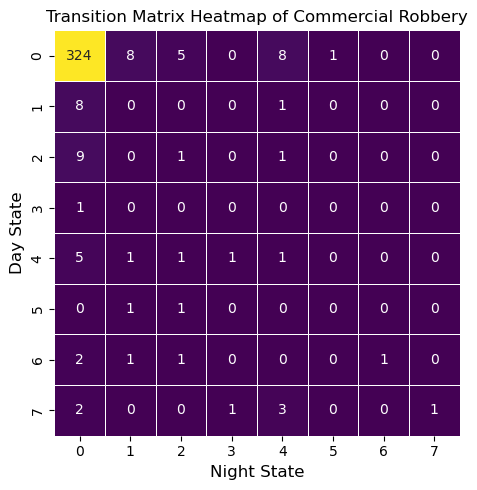


[2] Hierarchical Agglomerative Clustering with Complete Linkage
Silhouette (Scipy): 0.831
Silhouette (Sklearn): 0.831


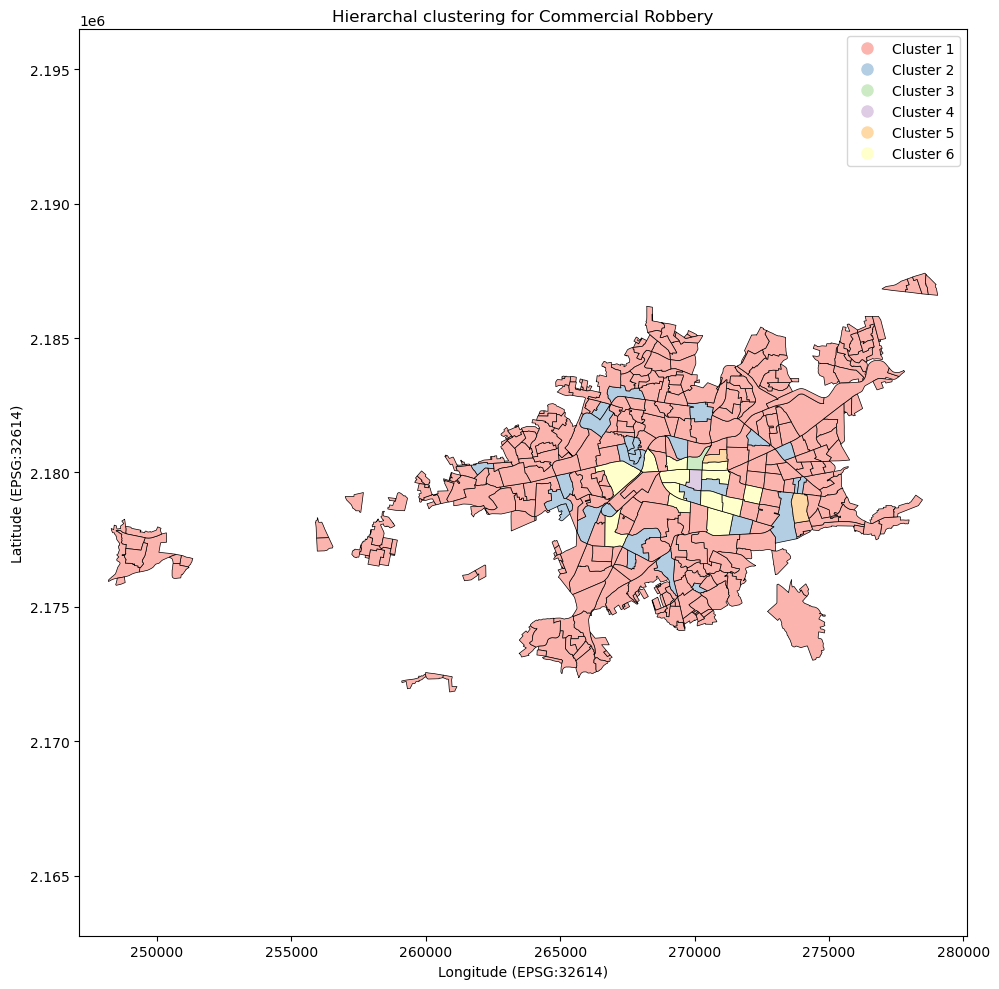


------------------------------------------------------------
ANALYSIS SUCCESSFULLY COMPLETED
------------------------------------------------------------



In [7]:
labels1, groups1, sil1, T1, I1 = main( i_crime = 1, crime = "Commercial Robbery", n_clusters = 6, gdf_agebs = gdf_agebs, results_path='./Resultados_RoboComercios/')

# Vehicle Theft 


------------------------------------------------------------
STARTING DAYTIME-NIGHTTIME ANALYSIS
------------------------------------------------------------

[1] Transition matrix
Day state distribution: {0.0: 332, 1.0: 9, 2.0: 5, 3.0: 2, 4.0: 5, 5.0: 3, 6.0: 7, 7.0: 27}
Night state distribution: {0.0: 316, 1.0: 9, 2.0: 10, 3.0: 5, 4.0: 11, 5.0: 2, 6.0: 13, 7.0: 24}
Transition matrix:
 [[302.   5.   7.   3.   8.   1.   1.   5.]
 [  4.   0.   1.   0.   2.   0.   0.   2.]
 [  0.   1.   0.   0.   0.   0.   2.   2.]
 [  1.   0.   0.   0.   0.   0.   1.   0.]
 [  1.   2.   0.   1.   0.   0.   1.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   3.]
 [  3.   0.   0.   0.   1.   0.   2.   1.]
 [  5.   1.   2.   1.   0.   1.   6.  11.]]
Indices (A, D, P): (0.3409090909090909, 0.1590909090909091, 0.5, 0.005681818181818182)


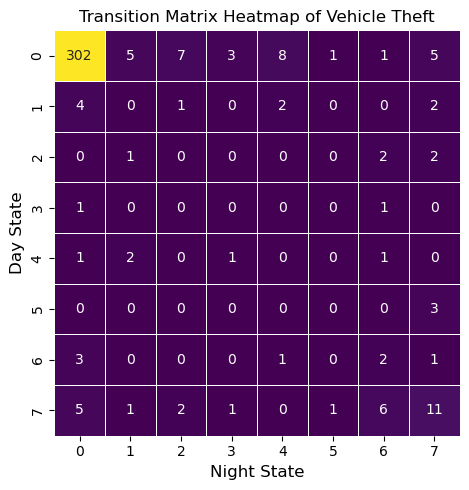


[2] Hierarchical Agglomerative Clustering with Complete Linkage
Silhouette (Scipy): 0.829
Silhouette (Sklearn): 0.829


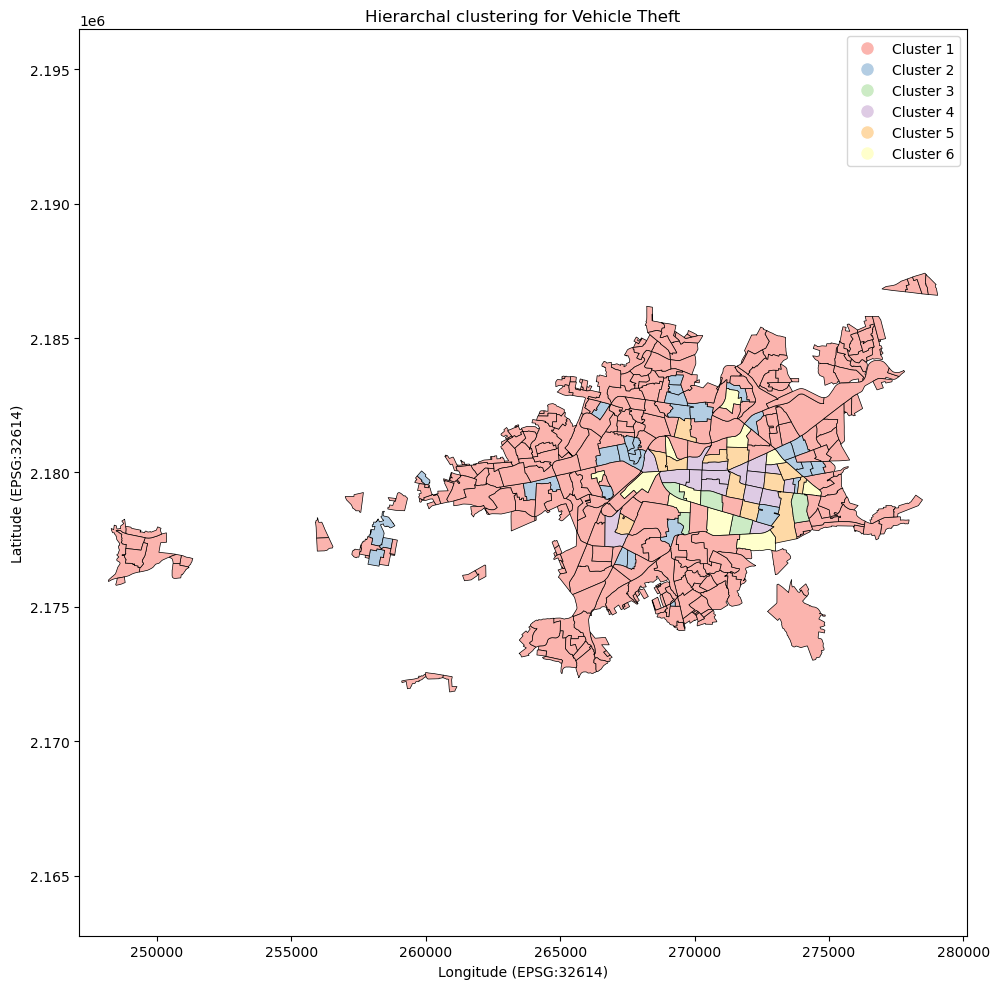


------------------------------------------------------------
ANALYSIS SUCCESSFULLY COMPLETED
------------------------------------------------------------



In [8]:
labels2, groups2, sil2, T2, I2 = main( i_crime = 2, crime = "Vehicle Theft", n_clusters = 6, gdf_agebs = gdf_agebs, results_path='./Resultados_RoboVehiculos/')

# Spider Chart

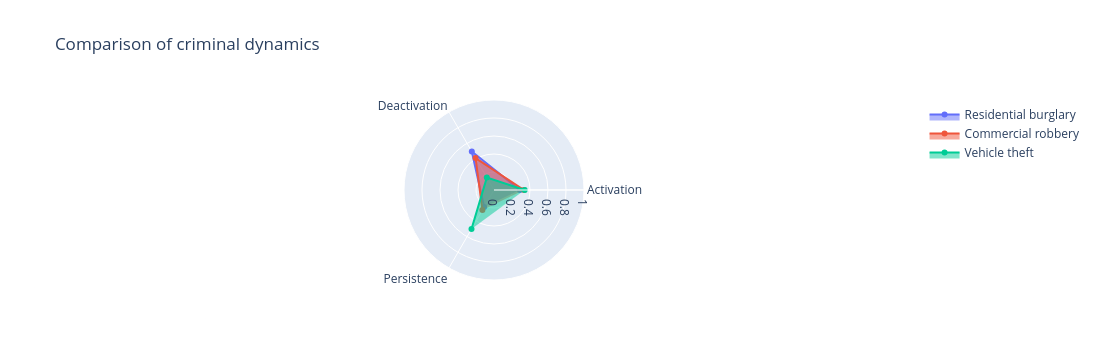

In [9]:
  try: 
    crimenes = [I0[:3],I1[:3],I2[:3]]
    nombres = ['Residential burglary', 'Commercial robbery', 'Vehicle theft']
    fig = radar_multiple(crimenes, nombres)
    fig.write_image("IRpatterns.png")
    fig.show() 
        
except Exception as e:
    print(f"Error creating spider chart: {e}")